# **Bank Telemarketing Dataset -- Macroeconomics EDA Approach**

In [1]:
## Import commonly used libraries
import pandas as pd 
import numpy as np  
import sidetable
import sklearn
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob
from itertools import combinations

## Display Setting

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')

In [3]:
file = []
data_path = Path.cwd().parent.joinpath("data", "raw")
for f in data_path.glob("*"):
    file.append(f.name)

print(file)

['.gitkeep', 'bank-additional-full.csv', 'bank-additional-names.txt', 'bank-full.csv', 'info.txt']


In [4]:
tele_df = pd.read_csv(data_path.joinpath("bank-additional-full.csv"), sep=';')
tele_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
tele_df.shape

(41188, 21)

In [6]:
# Remove whitespaces, ., spaces and lowercase column names
tele_df.columns = tele_df.columns.str.strip().str.replace(".", " ").str.replace(" ", "_").str.lower()
tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [7]:
tele_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [8]:
# Check Missing values
import sidetable
miss_df = tele_df.stb.missing()
miss_df.query("percent > 0")

,missing,total,percent


**No Missing Value in give dataset for numeric variables, will explore this.**

**Missing Attribute Values for Categorical Variables:** There are several missing values in some categorical attributes, all coded with the "unknown" label. These missing values can be treated as a possible class label or using deletion or imputation techniques.


**Social and Economic Context Data Description:**

- **emp.var.rate**: Employment variation rate - quarterly indicator (numeric)
- **cons.price.idx**: Consumer price index - monthly indicator (numeric)
- **cons.conf.idx**: Consumer confidence index - monthly indicator(numeric)
- **euribor3m**: Euribor 3-month rate - daily indicator(numeric)
- **nr.employed**: Number of employees - quarterly indicator(numeric)

**Target Variable:**
- **y**: Whether the client subscribed to a term deposit (binary: 'no', 'yes')


## **Formatting and Consistency check**

In [9]:
dtype_df = pd.DataFrame({
    'dtype': tele_df.dtypes,
    'nunique': tele_df.nunique(),
    'unique' : [tele_df[col].unique() for col in tele_df.columns]
}, index=tele_df.columns)
dtype_df

,dtype,nunique,unique
age,int64,78,"[56, 57, 37, 40, 45, 59, 41, 24, 25, 29, 35, 5..."
job,object,12,"[housemaid, services, admin., blue-collar, tec..."
marital,object,4,"[married, single, divorced, unknown]"
education,object,8,"[basic.4y, high.school, basic.6y, basic.9y, pr..."
default,object,3,"[no, unknown, yes]"
housing,object,3,"[no, yes, unknown]"
loan,object,3,"[no, yes, unknown]"
contact,object,2,"[telephone, cellular]"
month,object,10,"[may, jun, jul, aug, oct, nov, dec, mar, apr, ..."
day_of_week,object,5,"[mon, tue, wed, thu, fri]"


# **Exploratory Data Analysis -- Social Economic Context and bank related attributes**

**Social and Economic Context Data Description:**

- **emp.var.rate**: Employment variation rate - quarterly indicator (numeric)
    
    - **More on this:** Measure how much the employment changes over certian period of time(in this case, average over 3 months).

- **cons.price.idx**: Consumer price index - monthly indicator (numeric)

    - **More on this:** Tracks how the average prices of a fixed "basket" of goods and services(like food, housing, clothing, healthcare) change over time(in this case, 1 month)
- **cons.conf.idx**: Consumer confidence index - monthly indicator(numeric)
    - **More on this:** how optimistic or pessimistic consumer feel about their financial situation. When confidence is high, people tend to spend more, boosting economic growth; when confidence is low, they cut back, which can slow the economy.

**Related to bank**

- **euribor3m**: Euribor 3-month rate - daily indicator(numeric)
- **nr.employed**: Number of employees - quarterly indicator(numeric)

**Target Variable:**
- **y**: Whether the client subscribed to a term deposit (binary: 'no', 'yes')


**Target Variable**

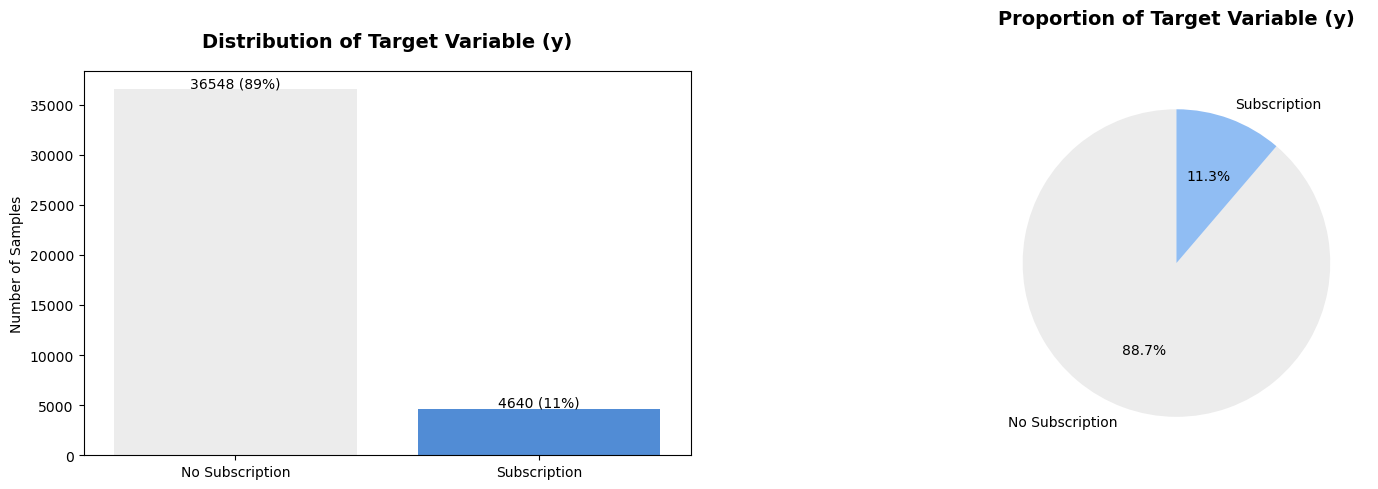

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
# Countplot for target variable
sns.countplot(
    data=tele_df, x='y', 
    order=tele_df['y'].value_counts().index, 
    palette = ['#ececec', '#3B8AEB90'],
    ax=ax[0])

ax[0].set_title('Distribution of Target Variable (y)', fontsize=14, fontweight='bold', y=1.04)
ax[0].set_xlabel('')
ax[0].set_ylabel('Number of Samples')
ax[0].set_xticks([0, 1], labels = ['No Subscription', 'Subscription'], rotation=0)

# Add percentage labels on bars
for i, v in enumerate(tele_df['y'].value_counts()):
    percentage = 100 * v / len(tele_df)
    ax[0].text(i, v + 200, f"{v} ({percentage:.0f}%)", ha='center', fontsize=10)

# Pie chart for target variable
tele_df['y'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    colors = ['#ececec', "#3B8AEB90"], 
    startangle=90, labels = ['No Subscription', 'Subscription'],
    ax=ax[1])

ax[1].set_ylabel('')
ax[1].set_title('Proportion of Target Variable (y)', fontsize=14, fontweight='bold', y=1.10)

# Add layout adjustments
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

**Data is highly imbalanced, with a significant majority of customers not subscribing to the term deposit. This imbalance will need to be addressed in the modeling phase, possibly through techniques such as resampling or using algorithms that can handle class imbalance effectively.**

In [11]:
# Make y binary in next step:
tele_df['y_binary'] = tele_df['y'].map({'yes': 1, 'no':0})

## **Correlation Matrix**

In [12]:
numeric_cols = [col for col in tele_df.select_dtypes(['number']).columns]
cat_cols = [col for col in tele_df.select_dtypes(['object'])]

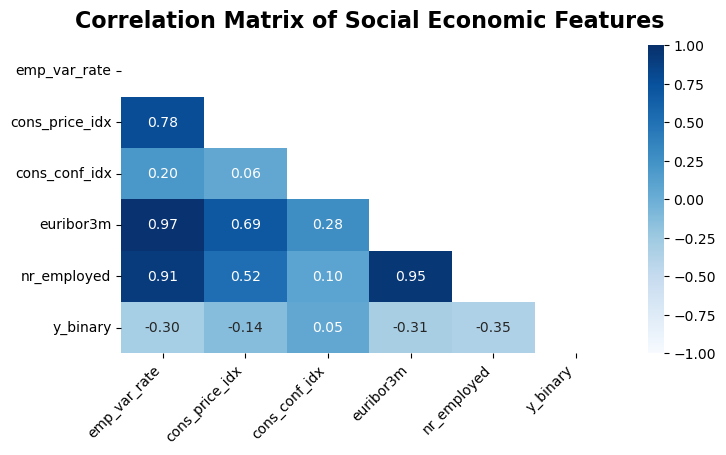

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
social_eco_df = tele_df[['emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'y_binary']]
corr_df = social_eco_df.select_dtypes(include='number').corr(method='pearson')
mask = np.triu(np.ones_like(corr_df, dtype=bool))

sns.heatmap(
    corr_df,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=-1,
    vmax=1,
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_title('Correlation Matrix of Social Economic Features', fontsize=16, fontweight='bold', y=1.03)
plt.show()


**Strong Correlation :**

- emp_var_rate and euribor3m (0.97)
- nr_employed and euribor3m (0.95)
- nr_employed and emp_var_rate (0.91)
- cons_price_idx and emp_var_rate (0.78)

**Moderate Correlation :**

- euribor3m and cons_price_idx (0.69)
- nr_employed and cons_price_idx (0.52)

**Other are weak positive/negative correlation**

**Considering the given dataset is about customer subscribe for term deposit will depends on each customers monthly economic and social context and, undoubtedly,economic factors had an impact on customer's decision i.e., target y. Hence, decide to analyze deeper the month dimension.**

In [14]:
# Just a remainder: the observations are ordered by date (from May 2008 to November 2010.
months_arr = [
    [i, m] for i, m in enumerate(tele_df['month'])
    if i ==0 or m != tele_df['month'].iloc[i-1]
]
months_arr = np.array(months_arr)


We got:

**2008 : [0, 27690)**

**2009 : [27690, 39130)**

**2010 : [39130, 41188)**

In [15]:
# create year as column
tele_df['year'] = np.hstack(
    (np.array([2008] * (27690 - 0)),
    np.array([2009] * (39130 - 27690)),
    np.array([2010] * (41188 - 39130)))
)
tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'y_binary', 'year'],
      dtype='object')

In [16]:
# Universal month order
order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
tele_df['month_order'] = pd.Categorical(tele_df['month'],categories=order, ordered=True)


In [17]:
list_cols = social_eco_df.columns.to_list()
list_cols.append('year')
social_eco_df = tele_df[list_cols]
social_eco_df.head()

,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,y_binary,year
0,1.1,93.994,-36.4,4.857,5191.0,no,0,2008
1,1.1,93.994,-36.4,4.857,5191.0,no,0,2008
2,1.1,93.994,-36.4,4.857,5191.0,no,0,2008
3,1.1,93.994,-36.4,4.857,5191.0,no,0,2008
4,1.1,93.994,-36.4,4.857,5191.0,no,0,2008


## **Dimension Analysis**

**Dimension : `emp_var_rate`**

emp_var_rate : employment variation rate -- quarterly inidcator (numeric)


Despite of **emp_var_rate** is a numeric feature, it has a small number of unique values:  

In [31]:
def numeric_nature(df, numeric_var):

    unique_values = df[numeric_var].nunique()
    var_range = f"{df[numeric_var].min()}  to  {df[numeric_var].max()}"
    values_count = df[numeric_var].value_counts()

    return unique_values, var_range, values_count

In [32]:
unique_values, var_range, values_count = numeric_nature(social_eco_df, 'emp_var_rate')
print(f"Number of unique Values : {unique_values}\n")
print(f"Values vary from : {var_range}")
print(f"\n{values_count}")


Number of unique Values : 10

Values vary from : -3.4  to  1.4

emp_var_rate
 1.4    16234
-1.8     9184
 1.1     7763
-0.1     3683
-2.9     1663
-3.4     1071
-1.7      773
-1.1      635
-3.0      172
-0.2       10
Name: count, dtype: int64


**Seaonal Trend in `emp_var_rate`**

Just getting a general view how emp_var_rate looks throughout all 3 consecutive years.

In [82]:
def numeric_var_by_year(df, xcol, ycol, hue_col, fig=None, ax=None):
    """Plot numeric variable distribution by consecutive year"""
    if fig is  None or ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    # numeic variable by seaonal_variable
    sns.lineplot(data = df, x = xcol, y = ycol, hue=hue_col, palette='tab10', ax = ax[0])

    ax[0].set_title(f"{ycol.replace("_", " ").capitalize()}  by {hue_col.capitalize()}", fontsize=16, fontweight='bold', y=1.10)
    ax[0].set_xlabel(" ")
    # unified legend
    lines, labels = ax[0].get_legend_handles_labels()
    fig.legend(lines, labels, bbox_to_anchor=(0.29, 0.9), loc='upper center', ncols=3, frameon=False)
    ax[0].legend_.remove()
    # Overall numeric variable plot
    sns.lineplot(data=df, x=xcol, y=ycol, hue=None, ax=ax[1])
    ax[1].set_xlabel(" ")
    ax[1].set_title(f"Overall distribution of {ycol.replace("_", " ").capitalize()}", fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()

    return fig, ax


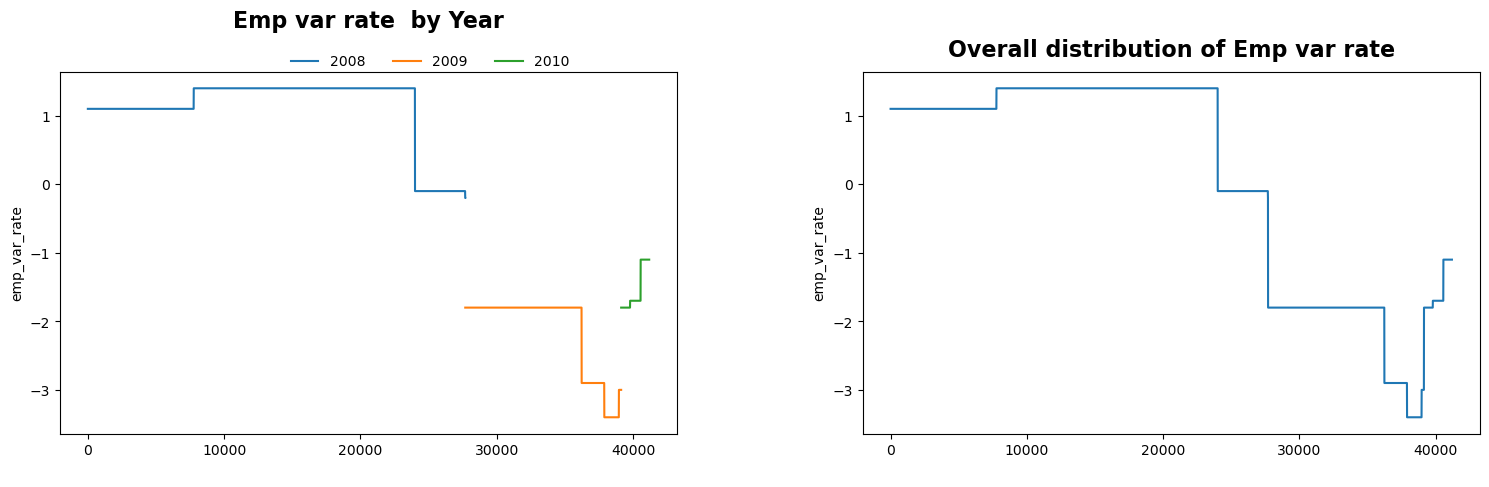

In [83]:
fig, ax = plt.subplots(1,2, figsize=(15, 5))
numeric_var_by_year(social_eco_df, social_eco_df.index, 'emp_var_rate', 'year', fig=fig, ax=ax);


**Observations:**

- 2008 : the rate was pretty stable and a bit growing, except for the year ending(it dropped).
- 2009 : stable for inital period, then decreased, and at very end of 2009 it started to grow.
- 2010 :the rate was growing up.

Now, let's see how YES-proportion correlates with emp_Var_rate by month and year and throughout entire dataset.

In [22]:
def plot_overall_yes_proportion(df, var1, var2, by_col, display_var, fig=None, ax=None):
    """Plot numeric variables median value for seasonal trend with overall and yes-proportion data"""  

    # Overall data
    total_df = pd.crosstab(
        df[var1], df[var2],
        df[by_col], aggfunc='median'
    )
    
    # yes-proportion data
    new_df = df[df['y']=='yes']
    yes_df = pd.crosstab(
        new_df[var1], new_df[var2],
        new_df[by_col], aggfunc='median'
    )
    # Visualization
    if fig is None or ax is None:
        fig, ax = plt.subplots(1,2, figsize=(15, 5))
    sns.heatmap(total_df, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax = ax[0])
    ax[0].set_yticklabels(ax[0].get_yticklabels(), rotation=25)
    ax[0].set_title(f"Overall median '{by_col}' by {display_var.capitalize()} and {var2.capitalize()}", fontsize=14,fontweight='bold', y=1.02)

    sns.heatmap(yes_df, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax = ax[1])
    ax[1].set_yticklabels(ax[0].get_yticklabels(), rotation=25)
    ax[1].set_title(f"YES-proportion median '{by_col}' by {display_var.capitalize()} and {var2.capitalize()}", fontsize=14, fontweight='bold', y=1.02)

    
    plt.show()

    return fig, ax

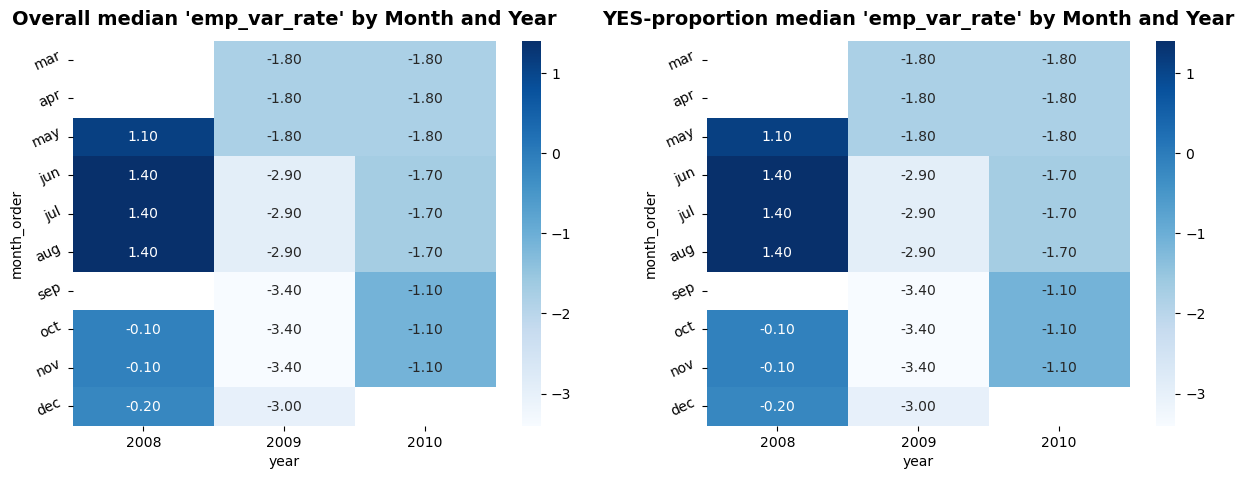

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_overall_yes_proportion(tele_df, 'month_order', 'year', 'emp_var_rate', 'month', fig, ax);


Median value of emp_var_rate by month and year is same for overall and yes-proportion data these variables are not good enough to differeniate emp_var_rate.

In [84]:
def plot_num_var_yes_prop(df, feature_name, y_binary, fig=None, ax = None):
    # Compute cumulative YES-proportion
    cumulative_yes_proportion = np.cumsum(df[y_binary]) / np.arange(1, df.shape[0] + 1)

    # Plot
    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    ax2 = ax.twinx()

    sns.lineplot(x=df.index, y=df[feature_name], color='b', ax=ax, label=feature_name, legend=False)
    sns.lineplot(x=df.index, y=cumulative_yes_proportion, color='r', ax=ax2, label='Cumulative YES-proportion', legend=False)

    # Styling
    ax.set_ylabel(feature_name, color='b')
    ax2.set_ylabel('YES-proportion', color='r')
    ax.tick_params(axis='y', colors='b')
    ax2.tick_params(axis='y', colors='r')
    ax.set_xlabel(" ")
    ax2.set_xlabel(" ")

    # Mark years
    year_indexes = [0, 27690, 39130]
    year_labels = [2008, 2009, 2010]
    for idx in year_indexes:
        ax.axvline(x=idx, ls='--', c='grey')
    ax.set_xticks(year_indexes, year_labels)

    # Unified legend 
    lines, labels = ax.get_legend_handles_labels() 
    lines2, labels2 = ax2.get_legend_handles_labels() 
    fig.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, frameon=False)
    
    fig.suptitle(f'{feature_name} vs YES-proportion entire dataset', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return fig, ax


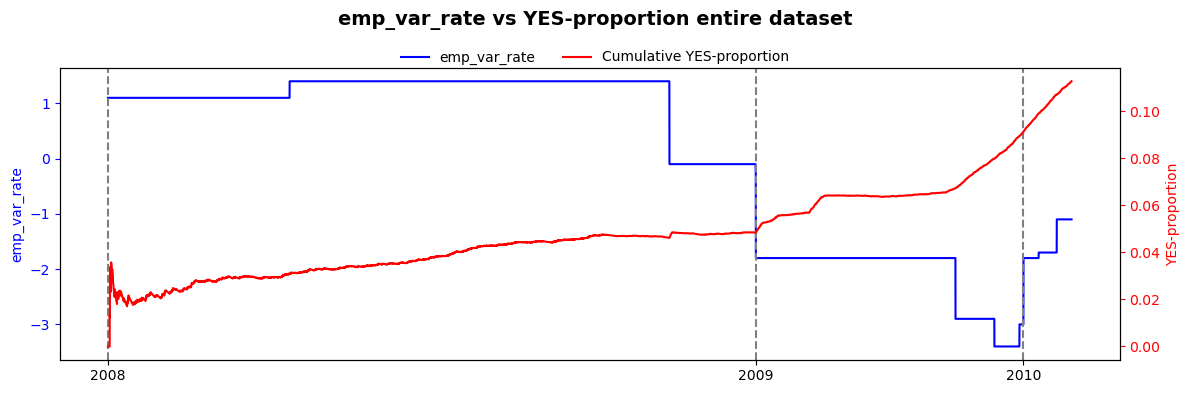

In [85]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_num_var_yes_prop(tele_df, 'emp_var_rate', 'y_binary', fig, ax);

In [26]:
# Correlation with term deposit
feature_name = 'emp_var_rate'
print(f"Pearson Correlaton Coeff ({feature_name} vs y) : {tele_df[feature_name].corr(tele_df['y_binary']):.4f}")

Pearson Correlaton Coeff (emp_var_rate vs y) : -0.2983


As you see, it is a weak negative correlation. That means, the higher employment variation rate - the lower YES-proportion we got, and vice versa. And that seems quite reasonable: if the employment rate is highly various, people are not sure about their future and tend to make cautious decisions - so they give YES-answer less frequent. But we should be careful here and recall that correlation is not causation.

Check descriptive statistics distribution of Yes-No answers.

In [124]:
def plot_yes_no_observation(df, xcol, feature_name, fig=None, ax=None):
    """Plot distribution of numeric feature by yes-no answer"""
    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(data=df, x=xcol, y=feature_name, color='b',
                medianprops={'ls':'-', 'lw':2.5, 'color':'r',
                'marker': 'o', 'markersize':6,'markerfacecolor':'white', 'markeredgecolor':'k'})
    
    bbox_props = dict(boxstyle='round', edgecolor='k', facecolor='white', alpha=0.9)
    median_no, median_yes = df.groupby([xcol])[feature_name].median()
    plt.text(1.6, ax.get_ylim()[1], f"No Meidan = {median_no:.2f}\nYes Median = {median_yes:.2f}",
             ha='left', va='center', fontsize=14, color='k', bbox=bbox_props)
    
    ax.set_title(f"Distribution of {feature_name} by {xcol}", fontsize=14, fontweight='bold', y=1.02)
    plt.show()

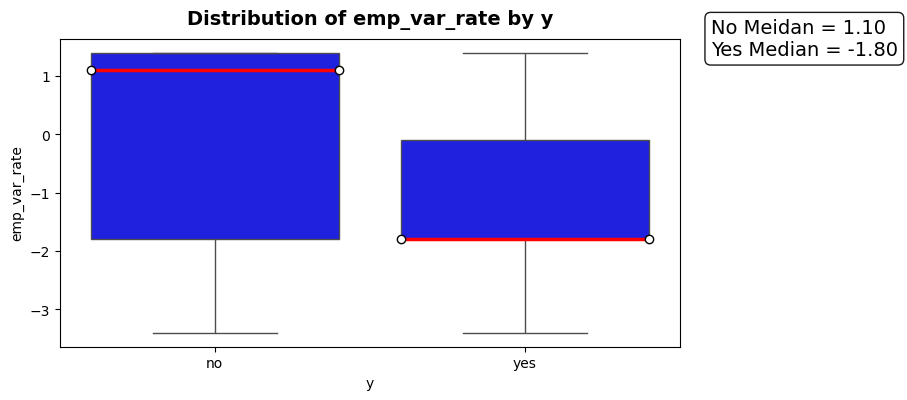

In [125]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_yes_no_observation(tele_df, 'y', 'emp_var_rate', fig, ax)

In [88]:
print("Various descriptive statistics of `emp_var_rate` by `y`\n")
print(tele_df.groupby(['y'])['emp_var_rate'].describe().round(2))

Various descriptive statistics of `emp_var_rate` by `y`

       count  mean   std  min  25%  50%  75%  max
y                                                
no   36548.0  0.25  1.48 -3.4 -1.8  1.1  1.4  1.4
yes   4640.0 -1.23  1.62 -3.4 -1.8 -1.8 -0.1  1.4


Clearly, there is huge difference between yes-no median and that's why this feature is useful for classification. Furthur, can be used of statistical analysis as well for more evidence.

In [29]:
# Compute Variance by year of numeric variable
def var_by_year(df, var1, var2):
    """Compute Variance by year of numeric variable"""
    results = []
    yearly_var = df.groupby([var1])[var2].var().round(2)
    yearly_observ = round(df[var1].value_counts(normalize=True)*100, 1)
    df = pd.concat([yearly_var, yearly_observ], axis='columns')    
    df.columns = [f'variation of `{var2}`', 'Number of observatios(%)']

    return df

    

In [30]:
var_by_year(tele_df, 'year', 'emp_var_rate')

,variation of `emp_var_rate`,Number of observatios(%)
year,,
2008,0.24,67.2
2009,0.33,27.8
2010,0.09,5.0


Both 2008 and 2009 have a higher employment variation rate and that's about 95% of all observations. As we all know, 2008 and 2009 were the years of the global financial crisis, so those 95% were obtained during a quite hard time for economy.

**Conclusion:**
- Values :
    - Number of unique values: 10
    - Vary from -3.4 to 1.4
- There is a weak negative correlation (-0.3) between emp.var.rate and YES-proportion, but not enough to predict term-deposit.
- There is a huge difference between medians of emp.var.rate for YES/NO-answers.
- 95% of answers were obtained during a quite hard time for economy and people.


**Dimension : `cons_price_idx`**

cons_price_idx : Consumer Price Index --- monthly indicator

Distribution of cons_price_idx:

In [96]:
unique_values, values_range, values_count = numeric_nature(social_eco_df, 'cons_price_idx')
print(f"Number of unique values : {unique_values}\n")
print(f"Values Range : {values_range}")


Number of unique values : 26

Values Range : 92.201  to  94.767


**Seasonal trend in `cons_price_idx`**

General view if 'cons_price_idx' throughout all three consecutive years.

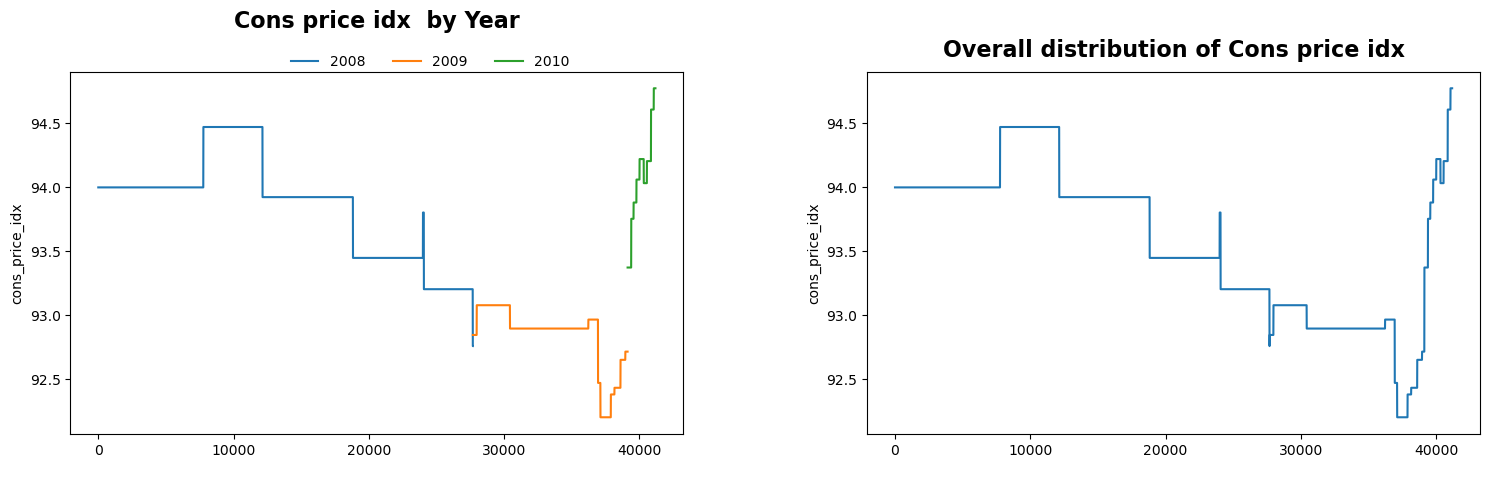

In [99]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
numeric_var_by_year(social_eco_df, social_eco_df.index, 'cons_price_idx', 'year', fig=fig, ax=ax);

**Observations:**
- 2008 and 2009 : Index was gradually decreasing with some short period of growth. And at the end of 2009 it start growing.
- 2010 : Prices dramatically went up.

Now, let's see how YES-proportion correlates with cons_price_idx by month and year and throughout entire dataset.

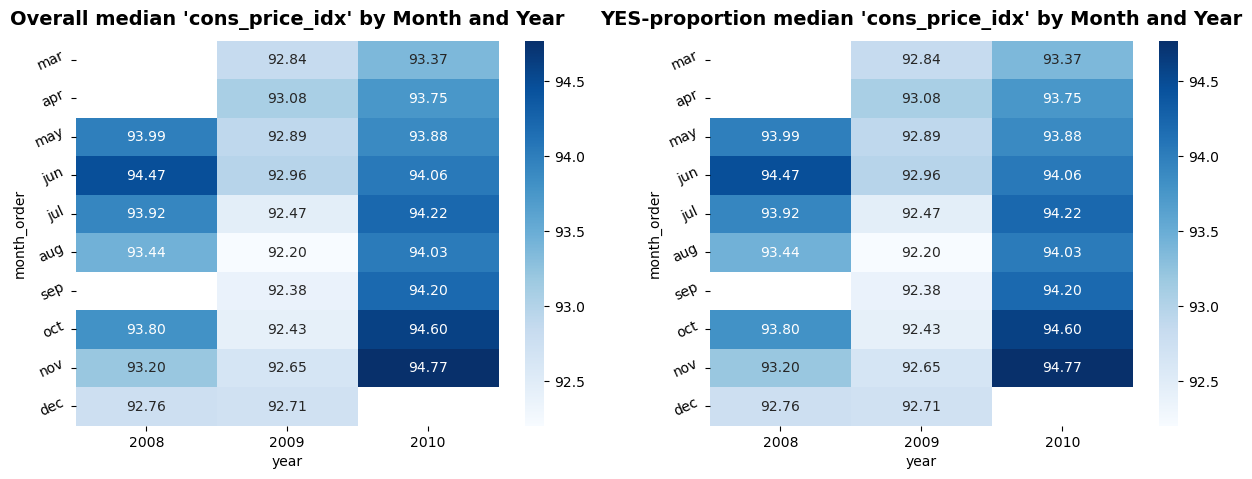

In [107]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_overall_yes_proportion(tele_df, 'month_order', 'year', 'cons_price_idx', 'Month', fig=fig, ax=ax);

Median values of cons_price_idx by month and year for overall and yes-proportion data is same. These variables are good enough to differentiate cons_price_idx for yes/no data.

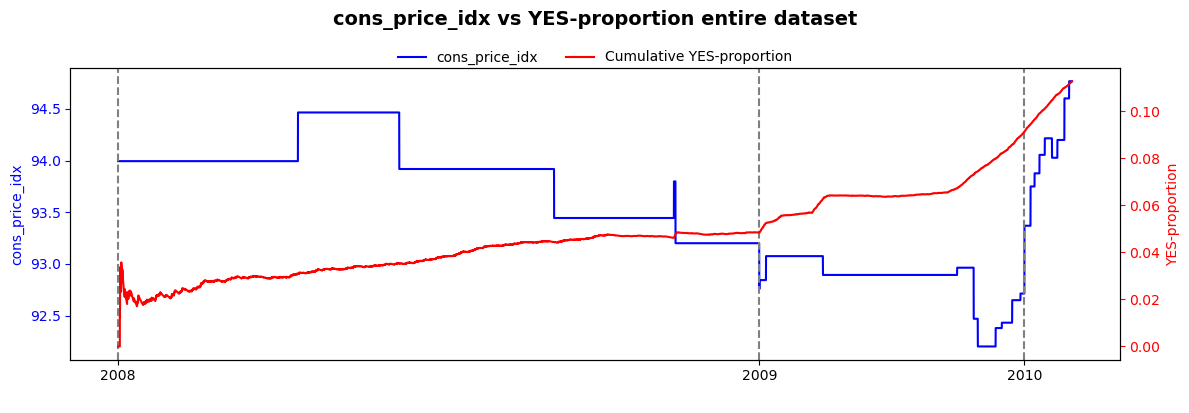

In [109]:
fig, ax = plt.subplots(figsize = (12, 4))
plot_num_var_yes_prop(tele_df, 'cons_price_idx', 'y_binary', fig=fig, ax=ax);

In [129]:
# Correlation with term deposit
feature_name = 'cons_price_idx'
print(f"Pearosn Correlation coeff (`{feature_name}` vs `y`) : {corr_df.loc[feature_name, 'y_binary']:.2f}")

Pearosn Correlation coeff (`cons_price_idx` vs `y`) : -0.14


**Interpretation :**
High `consumer price index (cons_price_idx)` --> consumers are less likely to subscribe(weak negative correlation).

Check descriptive statistics distribution of Yes-No answers.

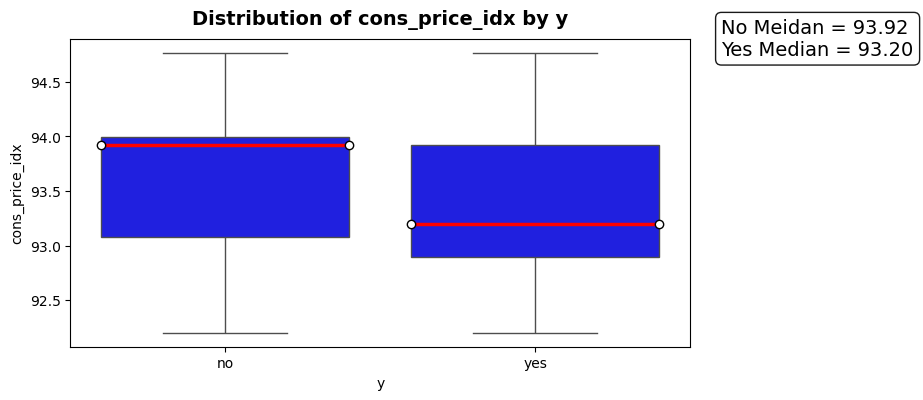

In [126]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_yes_no_observation(tele_df, 'y', 'cons_price_idx', fig=fig, ax=ax)

In [127]:
print("Various descriptive statistics of `emp_var_rate` by `y`\n")
print(tele_df.groupby(['y'])['cons_price_idx'].describe().round(2))

Various descriptive statistics of `emp_var_rate` by `y`

       count   mean   std   min    25%    50%    75%    max
y                                                          
no   36548.0  93.60  0.56  92.2  93.08  93.92  93.99  94.77
yes   4640.0  93.35  0.68  92.2  92.89  93.20  93.92  94.77


Clearly, there is huge difference between yes-no median and that's why this feature is useful for classification. Furthur, can be used of statistical analysis as well for more evidence.

In [128]:
# Compute variance in cons_price_idx by year
var_by_year(tele_df, 'year', 'cons_price_idx')

,variation of `cons_price_idx`,Number of observatios(%)
year,,
2008,0.15,67.2
2009,0.06,27.8
2010,0.14,5.0


- 2008 and 2010 were more stormy than 2009.
- CPI values were stable in 2009 which is good.
- CPI values were instable in 2008 and 2010 which indicate values fluctuate more within year.

In [130]:
print(f'Pearson corr. coef. (`{feature_name}` vs `emp.var.rate`): '
      f'{corr_df.loc[feature_name, 'emp_var_rate']:.2f}')

Pearson corr. coef. (`cons_price_idx` vs `emp.var.rate`): 0.78


Despite of strong correlation between cons.price.idx and emp.var.rate, 2009 was better than 2010 in terms of consumer prices.

**Conclusion:**
- Values :
    - Number of unique values : 26
    - Vary from -92.2 to 94.7
- There is a weak negative correlation (-0.14) between cons_price_idx and YES-proportion, but not enough to predict term-deposit.
- There is a huge difference between medians of cons_price_idx for YES/NO-answers.



**Dimension : `cons_conf_idx`**

cons_conf_idx : Consumer Confidence Index --- monthly indicator